<h2>Zadanie 3 Analiza obwodu elektrycznego - nadokreślony układ równań</h2>

In [ ]:
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt
from random import random, uniform, choice, sample

<h3>Metoda potencjałów węzłowych</h3>

In [2]:
def solve_circuit(edges, s, t, E):

    #szukamy liczbę wierszchołków
    n = max(s, t)
    for u, v, _ in edges: n = max(n, u, v)
    n+=1

    #tworzymy liczbę sąsiedstwa
    adj = [[] for _ in range(n)]

    for u, v, R in edges:
        adj[u].append((v, R))
        adj[v].append((u, R))

    #tworzymy macirzy i od razu zapisujemy odpowidzi
    #dla s oraz t bo wiemy
    A = np.zeros((n, n))
    B = np.zeros(n)
    
    A[s, s] = 1.0;  B[s] = 0.0
    A[t, t] = 1.0;  B[t] = E

    #dodajemy i odejmujemy przewodność zgodnie z metodą
    for i in range(n):
        if i in (s, t): continue

        sum_G = 0.0 
        for neighbor, R in adj[i]:
            G = 1.0 / R 
            sum_G += G
            
            A[i][neighbor] = -G
                
        A[i][i] = sum_G
        
    #rozwiązujmy równanie funkcją biblioteczną, bo jest szybsza od naszej
    #oraz tworzymy graf skierowany
    potentials = np.linalg.solve(A, B)
    G_dir = nx.DiGraph()
    
    I_emf = 0.0 
    for u, v, R in edges:
        I = (potentials[u] - potentials[v]) / R  

        #dodajmy krawiędzi do grafu zgodnie z kierunkiem prądu 
        src, dst = (u, v) if I >= 0 else (v, u)
        G_dir.add_edge(src, dst, current=abs(I), resistance=R)

        #dodatkowo dodaję i obliczam krawiędź dla siły elektromagnetycznej
        if t in (u, v):
            other = v if u == t else u
            I_emf += (potentials[t] - potentials[other]) / R
            

    G_dir.add_edge(s, t, current=I_emf, resistance=0.0, is_emf=True)
    return G_dir 

<h3>Wizualizacja</h3>

In [42]:
def visualize_circuit(G):

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)

    edges = G.edges(data=True)
    currents = [abs(data['current']) for _, _, data in edges]

    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=400, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=6, font_weight='bold')

    nx.draw_networkx_edges(
        G, pos,
        edgelist=G.edges(),
        arrowstyle='->',
        arrowsize=12,
        edge_color=currents,
        edge_cmap=plt.cm.plasma,
        edge_vmin=min(currents),
        edge_vmax=max(currents),
        width=1
    )

    edge_labels = {(u, v): f"{data['current']:.2f} A" for u, v, data in edges}
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=7,
        font_color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
    )

    sm = plt.cm.ScalarMappable(
        cmap=plt.cm.plasma,
        norm=plt.Normalize(vmin=min(currents), vmax=max(currents))
    )
    sm.set_array([])
    
    cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
    cbar.set_label('Current (Amperes)', fontsize=12)        
    plt.title("Electric Circuit Current Visualization", fontsize=15, fontweight='bold')  
    plt.axis('off')
    plt.tight_layout()
    plt.show()

<h3>Sprawdzanie poprawności</h3>
Sparwdzamy poprawnośc algorytmu korzystając z I Prawa Kirchoffa

In [4]:
def verify(G):
    epsilon = 1e-9 

    for node in G.nodes():
        sum_in = sum(data['current'] for _, _, data in G.in_edges(node, data=True))
        sum_out = sum(data['current'] for _, _, data in G.out_edges(node, data=True))
        

        if abs(sum_in - sum_out) >= epsilon: return False

    return True

In [5]:
#funkcja pomocnicza
def to_edges(G):
    edges_with_resistance = []
    
    for u, v in G.edges():
        resistance = uniform(1.0, 50.0) 
        edges_with_resistance.append((u, v, resistance))
        
    return edges_with_resistance

<h2>Generowanie różnych typów grafów</h2>
Używano do tego funkcji bibliotecznych

In [6]:
def generate_erdos_renyi(n, p=0.2):
    G_random = nx.erdos_renyi_graph(n, p)        
            
    return to_edges(G_random)

In [7]:
def generate_3regular(n):
    if n % 2 != 0:
        raise ValueError(f"n should be divisible by 2!")
    
    G_cubic = nx.random_regular_graph(3, n)
    return to_edges(G_cubic)

In [8]:
def generate_bridge_graph(n, p=0.5):
    n1 = n // 2
    n2 = n - n1
    
    G = nx.disjoint_union(nx.erdos_renyi_graph(n1, p),
                                    nx.erdos_renyi_graph(n2, p))
    
    left_range = range(n1)
    right_range = range(n1, n)
    
    G.add_edge(choice(left_range), choice(right_range))
    
    return to_edges(G), left_range, right_range

In [9]:
def generate_small_world(n, k=4, p=0.2):
    G_sw = nx.watts_strogatz_graph(n, k, p)

    return to_edges(G_sw)

In [10]:
def generate_2d_grid(rows, cols):
    G_grid = nx.grid_2d_graph(rows, cols)
    G_grid = nx.convert_node_labels_to_integers(G_grid)
    
    return to_edges(G_grid)

<h3>Funkcji do pracy z plikamy</h3>

In [11]:
def save_graph_to_file(filename, edges, s, t, E):
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(f"{s} {t} {E}\n")
        
        for u, v, R in edges:
            f.write(f"{u} {v} {R}\n")

    print("The file was uploaded successfully")

In [12]:
def load_graph_from_file(filename):
    edges = []
    
    with open(filename, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
        first_line = lines[0].strip().split()
        s = int(first_line[0])
        t = int(first_line[1])
        E = float(first_line[2])
        
        for line in lines[1:]:
                
            parts = line.strip().split()
            u = int(parts[0])
            v = int(parts[1])
            R = float(parts[2])
            edges.append((u, v, R))
            
    return edges, s, t, E

<h3>Testy</h3>

In [25]:
n_values = [16, 30, 50, 100, 200]
E = 100.0


def erdes_renyi_test():
    print("Erdes-Renyi")
    
    for n in n_values:
        print(f"n = {n}")

        edges = generate_erdos_renyi(n)
        s, t = sample(range(n), 2)
        G = solve_circuit(edges, s, t, E)

        if verify(G): print("success")
        else: print("error")

erdes_renyi_test()

Erdes-Renyi
n = 16
success
n = 30
success
n = 50
success
n = 100
success
n = 200
success


In [26]:
def regular3_test():
    print("3 regular")

    for n in n_values:
        print(f"n = {n}")

        edges = generate_3regular(n)
        s, t = sample(range(n), 2)
        G = solve_circuit(edges, s, t, E)

        if verify(G): print("success")
        else: print("error")
        
regular3_test()

3 regular
n = 16
success
n = 30
success
n = 50
success
n = 100
success
n = 200
success


In [30]:
def bridge_test():
    print("bridge")

    for n in n_values:
        print(f"n = {n}")

        edges, left_nodes, right_nodes = generate_bridge_graph(n)
        s = choice(left_nodes)
        t = choice(right_nodes)
        G = solve_circuit(edges, s, t, E)

        if verify(G): print("success")
        else: print("error")
bridge_test()

bridge
n = 16
success
n = 30
success
n = 50
success
n = 100
success
n = 200
success


In [32]:
def sm_test():
    print("small world test")

    for n in n_values:
        print(f"n = {n}")

        edges = generate_small_world(n, k=4, p=0.2)
        s, t = sample(range(n), 2)
        G = solve_circuit(edges, s, t, E)

        if verify(G): print("success")
        else: print("error")

sm_test()

small world test
n = 16
success
n = 30
success
n = 50
success
n = 100
success
n = 200
success


In [34]:
grid_values = [(4, 4), (5, 5), (7, 7), (10, 10), (17, 17)]
def grid_2d_test():
    print("2d grid test")

    for rows, cols in grid_values:
        print(f"n = {cols * rows}")

        
        
        edges = generate_2d_grid(rows, cols)
        s = 0
        t = rows * cols - 1

        G = solve_circuit(edges, s, t, E)

        if verify(G): print("success")
        else: print("error")

grid_2d_test()


2d grid test
n = 16
success
n = 25
success
n = 49
success
n = 100
success
n = 289
success


<h3>Wizualizacja grafów</h3>

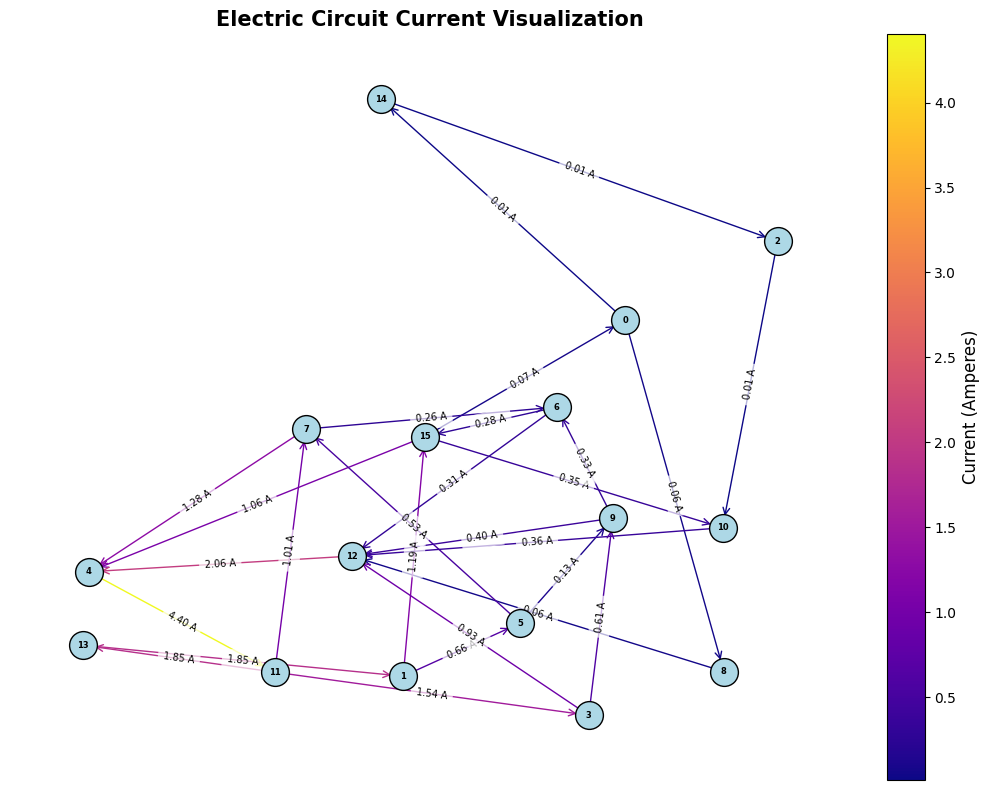

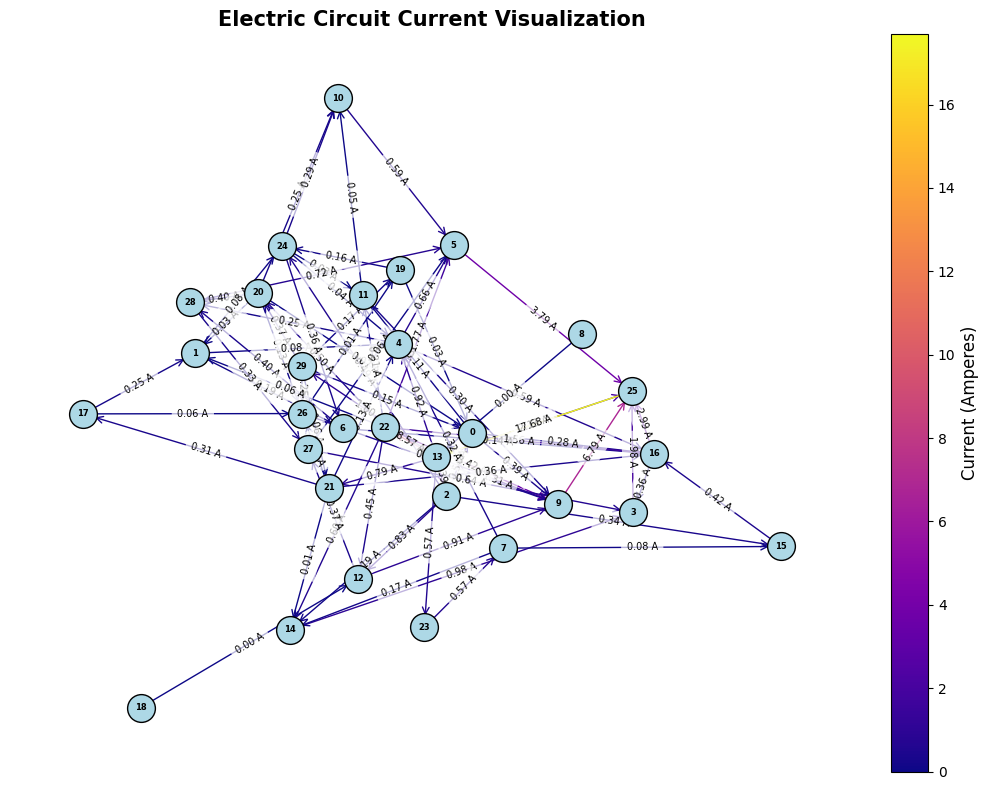

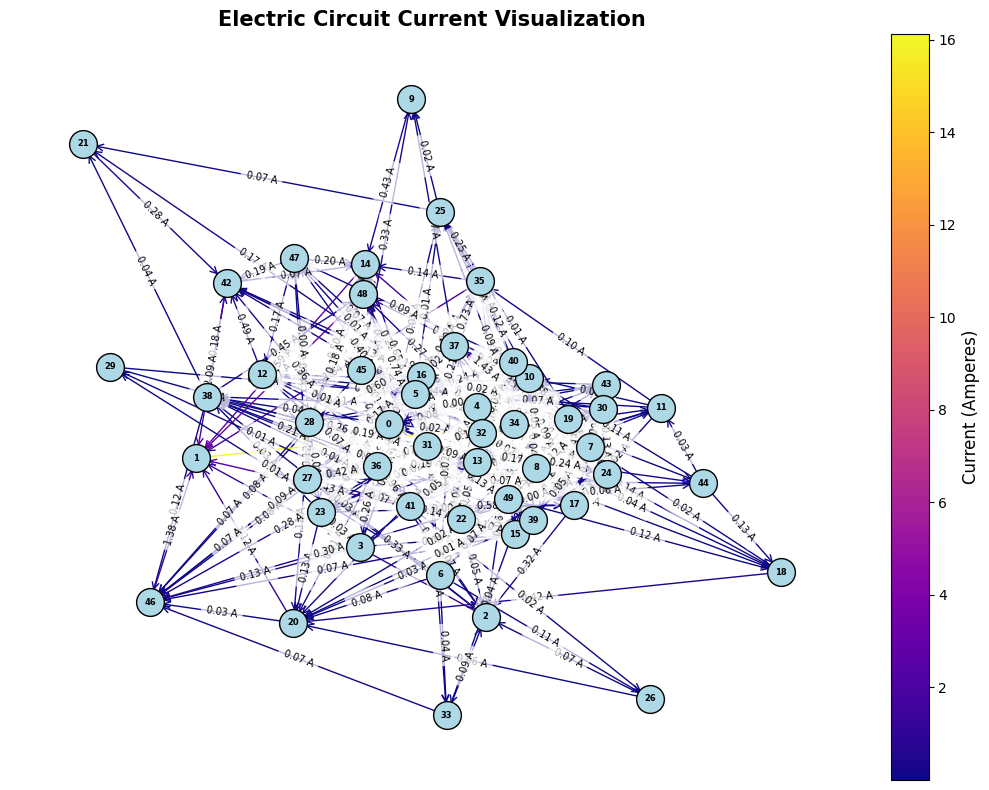

In [55]:
for n in [16, 30, 50]:
    edges = generate_erdos_renyi(n)
    s, t = sample(range(n), 2)
    G = solve_circuit(edges, s, t, E)
    result = verify(G)
    if result:
        visualize_circuit(G)

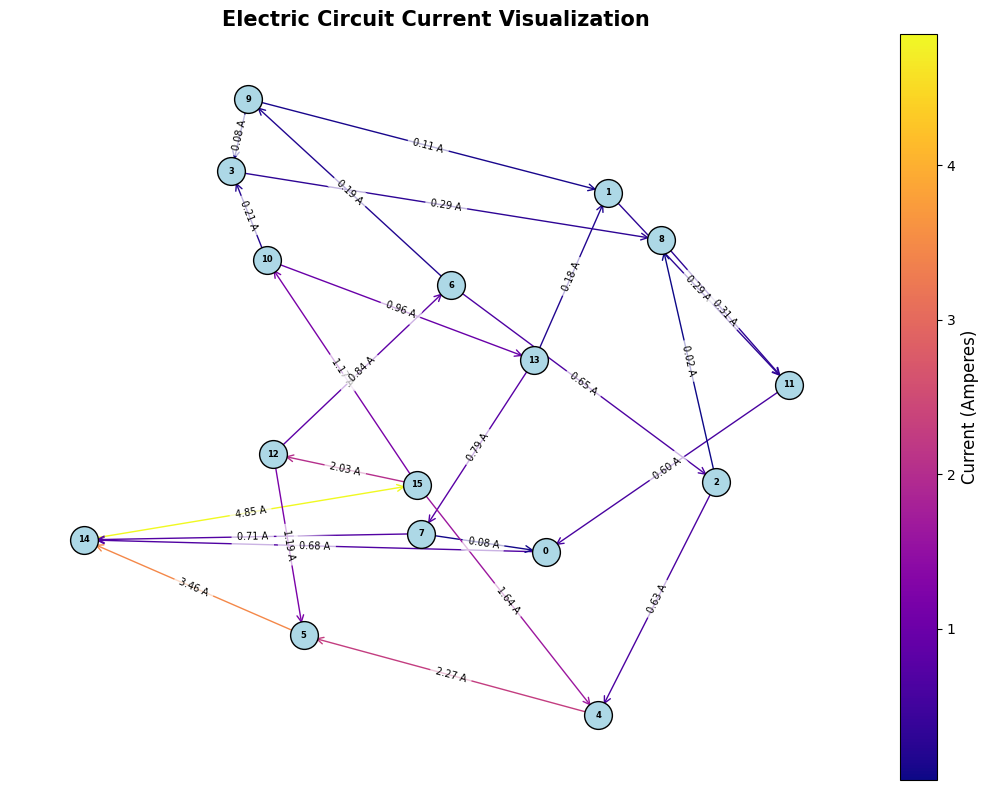

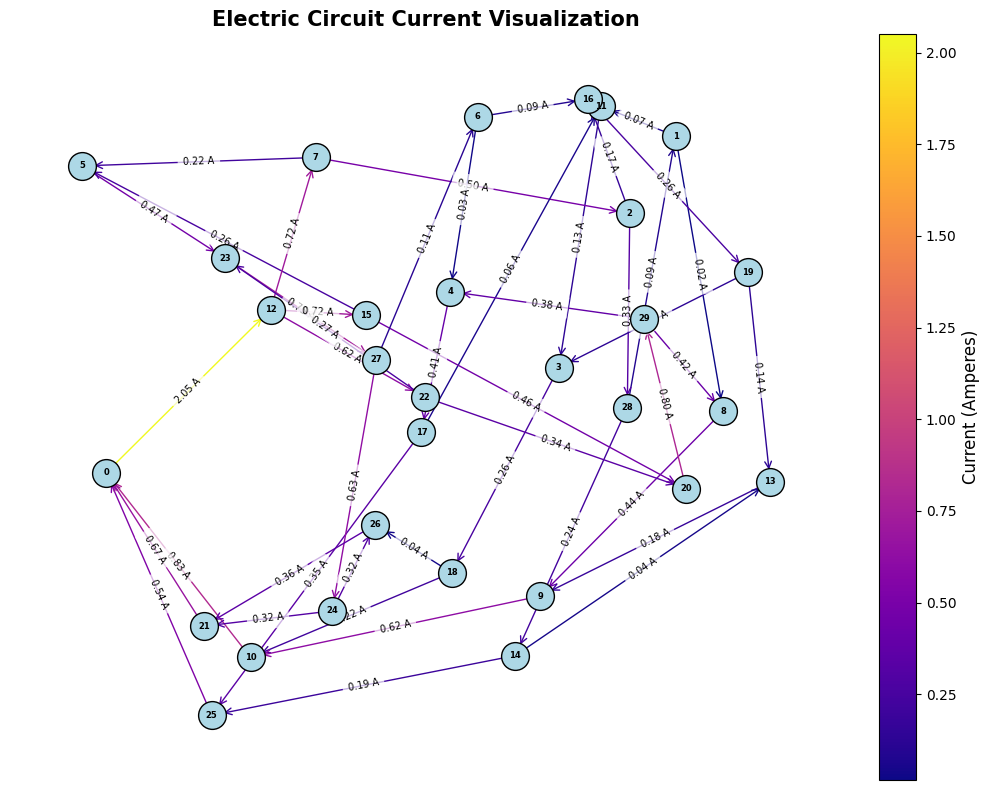

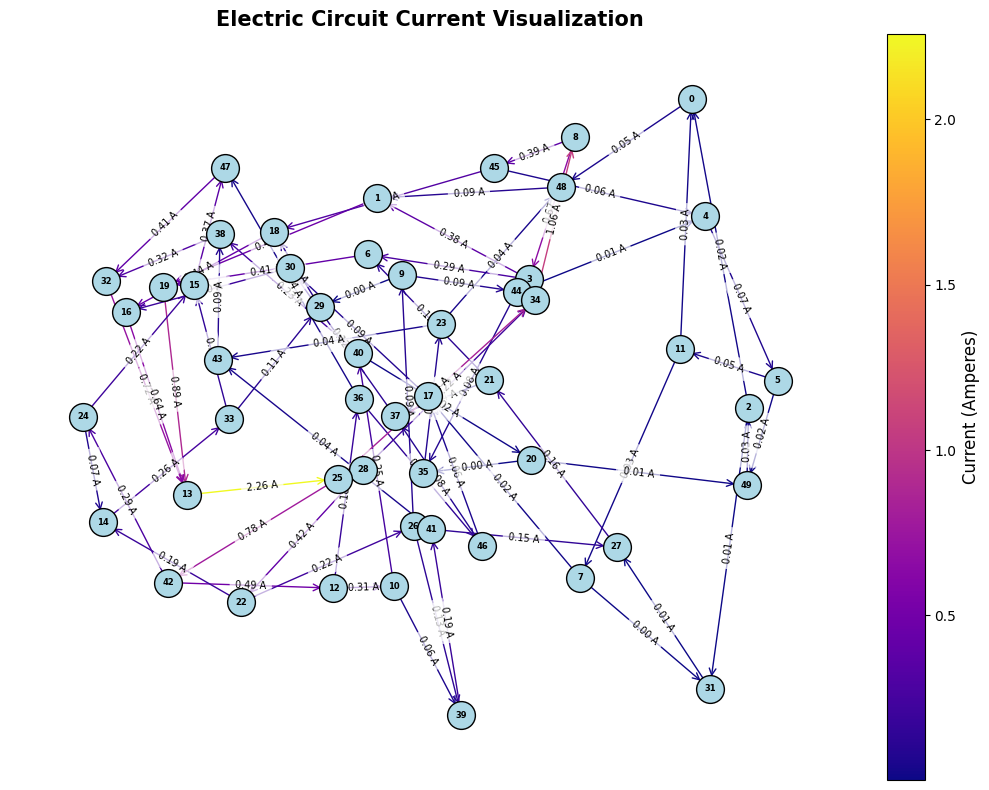

In [56]:
for n in [16, 30, 50]:
    edges = generate_3regular(n)
    s, t = sample(range(n), 2)
    G = solve_circuit(edges, s, t, E)
    result = verify(G)
    if result:
        visualize_circuit(G)

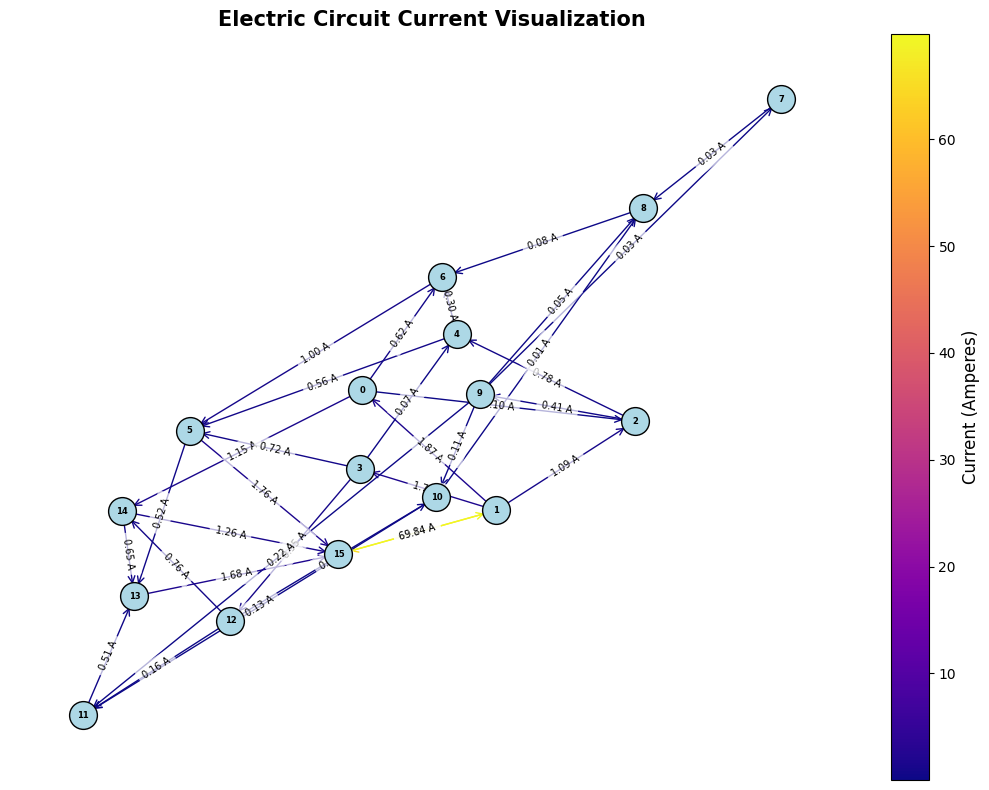

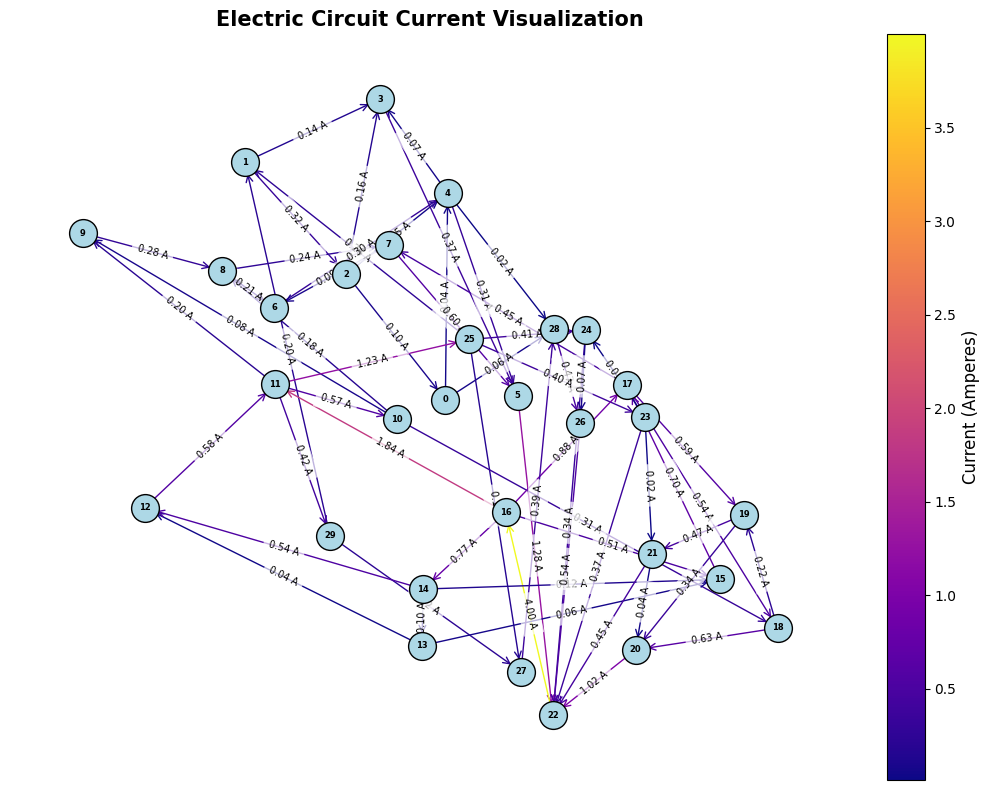

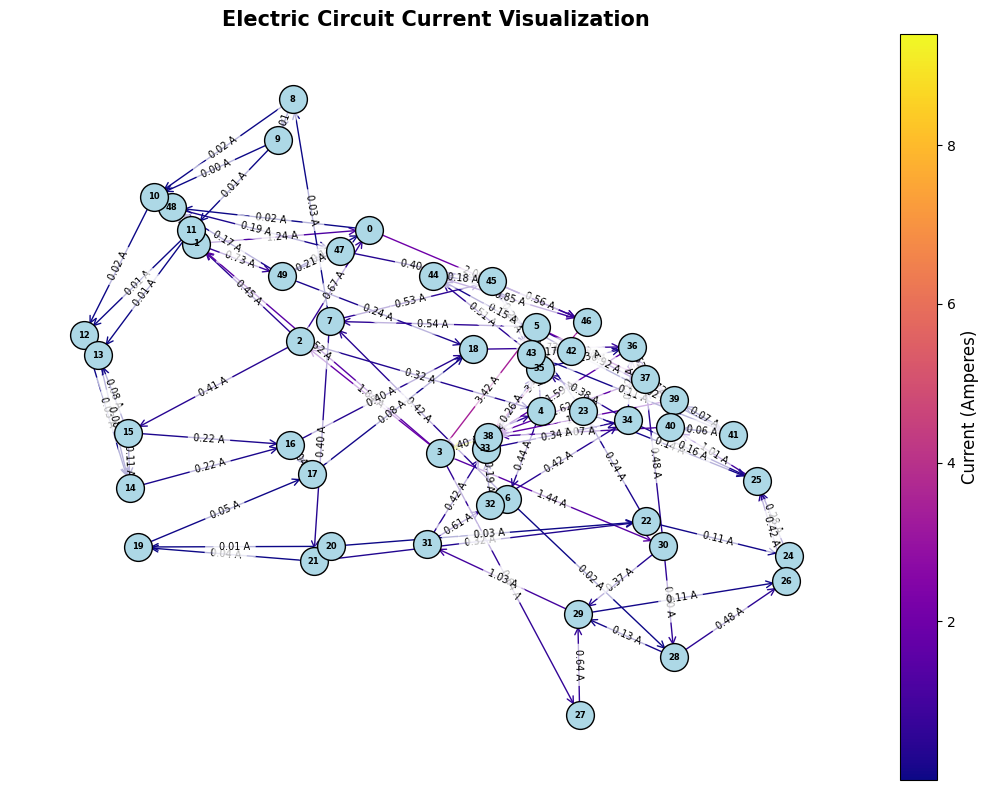

In [57]:
for n in [16, 30, 50]:
    edges = generate_small_world(n, k=4, p=0.2)
    s, t = sample(range(n), 2)
    G = solve_circuit(edges, s, t, E)
    result = verify(G)
    if result:
        visualize_circuit(G)

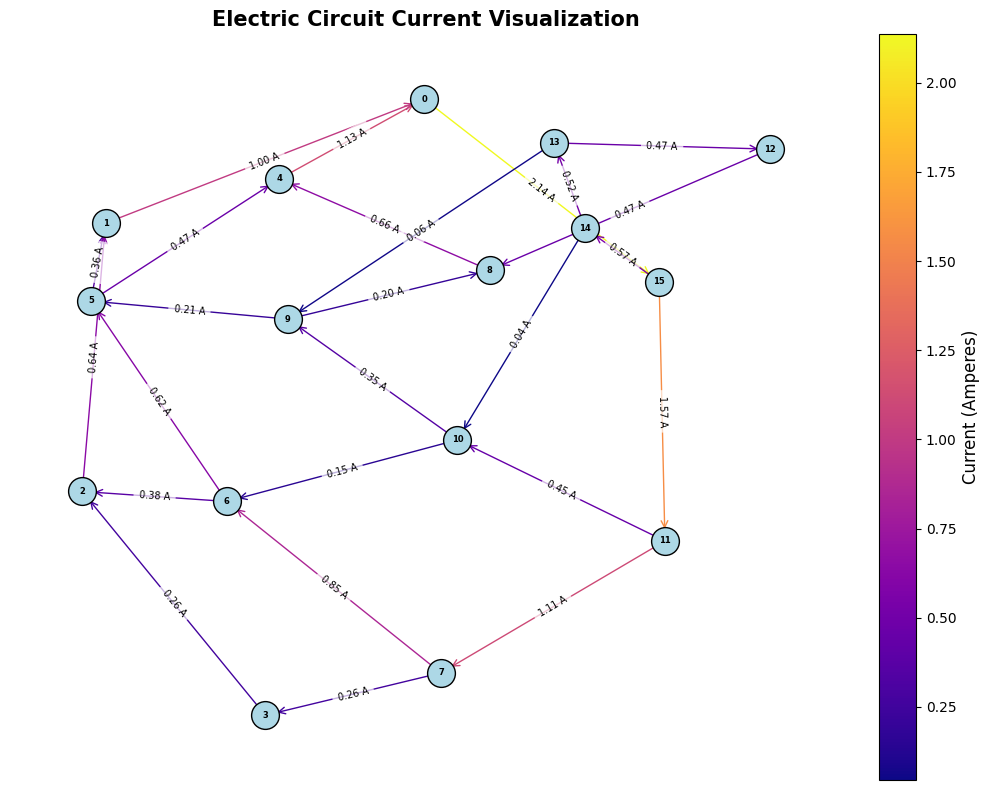

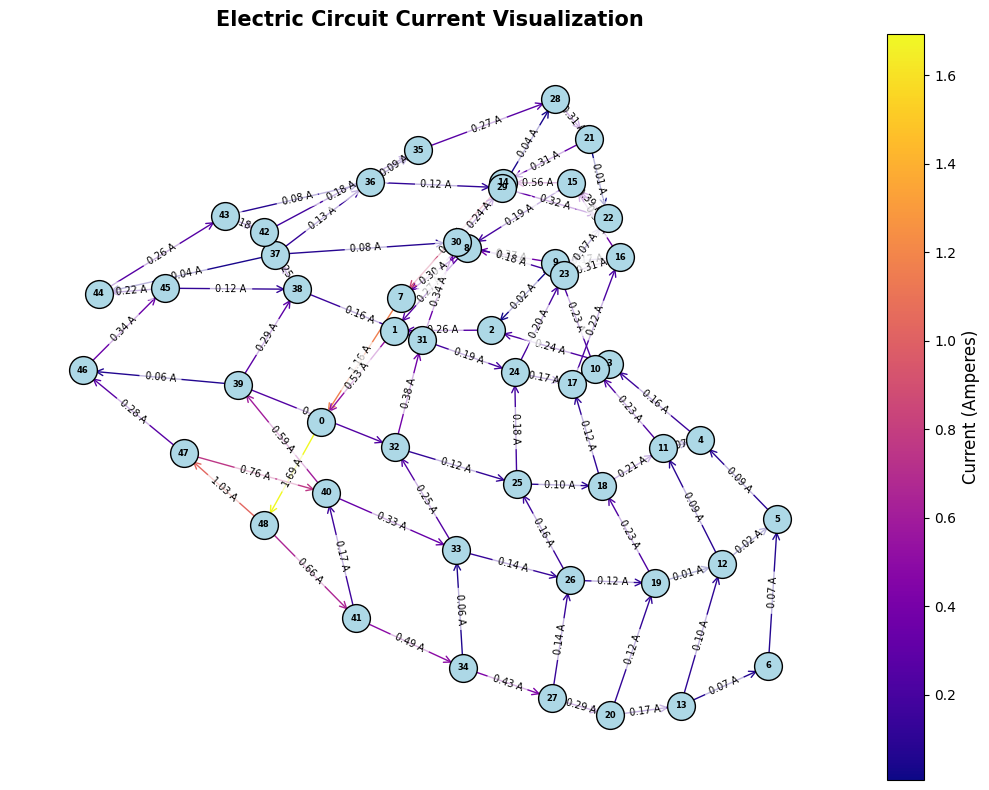

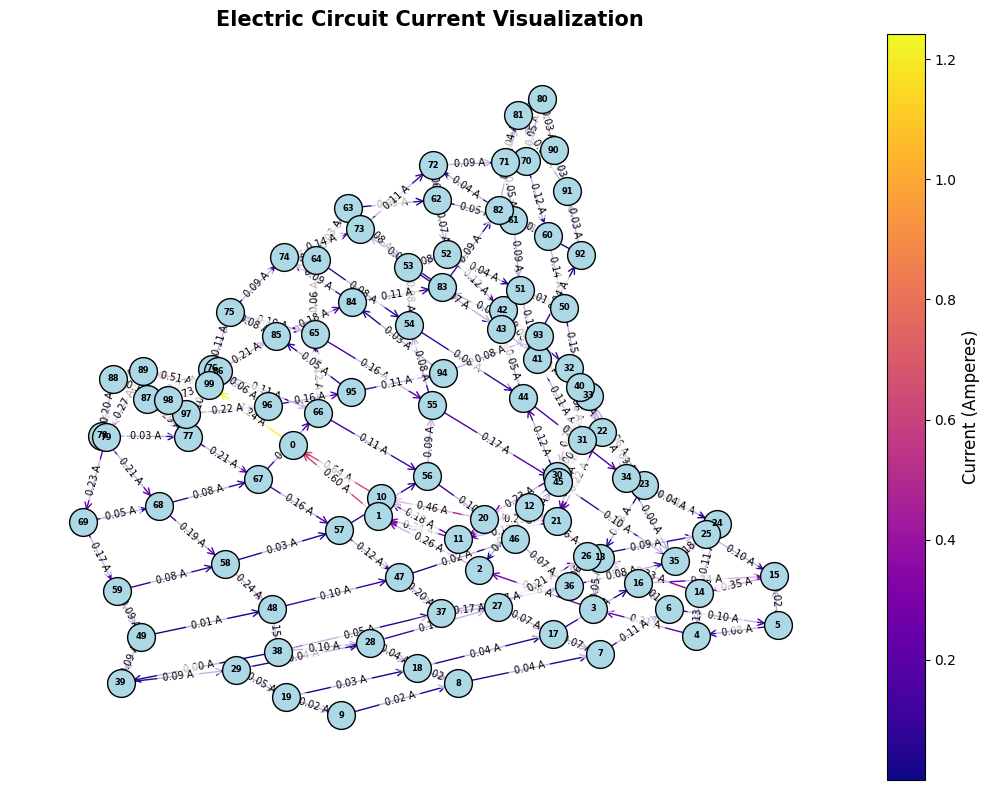

In [58]:
for rows, cols in [(4, 4), (7, 7), (10, 10)]:
    n_grid = rows * cols
    edges = generate_2d_grid(rows, cols)
    s = 0
    t = n_grid - 1
    G = solve_circuit(edges, s, t, E)
    result = verify(G)
    if result:
        visualize_circuit(G)